In [2]:
import pandas as pd
import numpy as np
import geopandas as gpd
from sklearn.metrics import f1_score, classification_report
from itertools import product
import matplotlib.pyplot as plt

maximize the macro F1 SCORE, balance the precision and recall, and find the optimal thresholds for categorizing data into 'H', 'M', and 'L' based on a score column and true labels.

In [3]:
validation_df = pd.read_csv('2026-03-11T22_05_20+00_00_urh.csv')
print(validation_df.columns)


Index(['id', 'created_at', 'validation', 'user_id', 'output_id',
       'output_model', 'output_model_city_name', 'output_model_city_country',
       'output_model_subdomain_name', 'output_result', 'output_latitude',
       'output_longitude'],
      dtype='object')


### Kano

In [ ]:
# Select pilot city
pilot = 'Kano'  # Change this to the desired pilot city
# Load PAR data and filter by pilot city
# par_expanded = pd.read_csv('/content/expanded_data.csv') # You need to upload this file
par_expanded = validation_df[validation_df['output_model_city_name'] == f'{pilot.capitalize()}']

In [5]:
# Describe the shape of the validation data
print("Shape of PAR Data", par_expanded.shape)
par_expanded['output_model_subdomain_name'].value_counts()

Shape of PAR Data (24810, 12)


output_model_subdomain_name
Morphological Informality                      11009
Emergency Obstetric Care Access Deprivation     4434
General Healthcare Access Deprivation           4038
Road Access Deprivation                         3581
Drinking Water Access Deprivation               1748
Name: count, dtype: int64

In [ ]:
# Enter subdomain
subdomain = 'Emergency Obstetric Care Access Deprivation'  # Change this to the desired subdomain

# Filter Data by Subdomain
par_subdomain = par_expanded[par_expanded['output_model_subdomain_name'] == subdomain]
par_subdomain.head()

,id,created_at,validation,user_id,output_id,output_model,output_model_city_name,output_model_city_country,output_model_subdomain_name,output_result,output_latitude,output_longitude
141,3e2c4ed2-5d70-4366-87cb-31b2fc708ad7,2025-05-22T14:30:43.470779+00:00,1.0,e039d820-cd6e-4360-b92b-8729c3354bd4,594583b8-21ac-40a7-8bad-47d5d4853571,4c44b4ef-407a-469c-af5d-185aa83c7133,Kano,Nigeria,Emergency Obstetric Care Access Deprivation,1,12.040564,8.572567
197,b9d75a79-f95b-474a-b635-ae5dabc701d4,2025-05-22T14:31:08.713542+00:00,1.0,e039d820-cd6e-4360-b92b-8729c3354bd4,f699230f-14d5-4309-a765-632849cbe817,4c44b4ef-407a-469c-af5d-185aa83c7133,Kano,Nigeria,Emergency Obstetric Care Access Deprivation,1,12.041379,8.573595
262,46c1fe60-2017-418a-9c8e-58fc9d3f0313,2025-05-22T14:31:12.345971+00:00,1.0,e039d820-cd6e-4360-b92b-8729c3354bd4,70f2736e-12a6-4eb2-9485-8538bdeade0f,4c44b4ef-407a-469c-af5d-185aa83c7133,Kano,Nigeria,Emergency Obstetric Care Access Deprivation,1,12.039748,8.574574
263,af24f34b-f8cf-4d1b-94fb-0aa451766abe,2025-05-22T14:31:17.362707+00:00,0.0,11072e21-e8b7-45e6-88ff-b1569e233941,59de5b75-eb3e-4c14-b789-57bae0f34653,4c44b4ef-407a-469c-af5d-185aa83c7133,Kano,Nigeria,Emergency Obstetric Care Access Deprivation,0,12.034854,8.563351
325,64490bd3-c8bf-4748-9e8a-249d070c7397,2025-05-20T11:51:06.297704+00:00,1.0,3617df69-2dae-48f8-b1dc-7f4809b0d7ad,c9d663ea-b9d9-461b-ab7a-67293f6c20f7,4c44b4ef-407a-469c-af5d-185aa83c7133,Kano,Nigeria,Emergency Obstetric Care Access Deprivation,1,11.995702,8.521111


In [ ]:
accessibility_index = gpd.read_file('deprivation-classification-Kano.gpkg')
print(accessibility_index.columns)


Index(['grid_id', 'longitude', 'latitude', 'lon_min', 'lon_max', 'lat_min',
       'lat_max', 'Accessibility_Index_Standard', 'result', 'focused',
       'geometry'],
      dtype='object')


In [8]:
# special validation results to the accessibility index dataset
accessibility_index = accessibility_index.merge(
    par_subdomain[['output_latitude', 'output_longitude', 'output_result', 'validation']],
    left_on  = [accessibility_index['latitude'].round(7), accessibility_index['longitude'].round(7)],
    right_on = [par_subdomain['output_latitude'].round(7), par_subdomain['output_longitude'].round(7)],
    how = 'inner'
).drop(columns=['output_latitude', 'output_longitude'])

print(accessibility_index.head())


       key_0     key_1  grid_id  longitude   latitude   lon_min   lon_max  \
0  12.096848  8.431029       16   8.431029  12.096848  8.430515  8.431543   
1  12.087059  8.445002       24   8.445002  12.087059  8.444488  8.445516   
2  12.087059  8.445002       24   8.445002  12.087059  8.444488  8.445516   
3  12.087059  8.447026       27   8.447026  12.087059  8.446512  8.447539   
4  12.087059  8.447026       27   8.447026  12.087059  8.446512  8.447539   

     lat_min    lat_max  Accessibility_Index_Standard  result  focused  \
0  12.096440  12.097256                      0.005863       1        1   
1  12.086651  12.087467                      0.014871       1        0   
2  12.086651  12.087467                      0.014871       1        0   
3  12.086651  12.087467                      0.018920       1        0   
4  12.086651  12.087467                      0.018920       1        0   

                                            geometry  output_result  \
0  POLYGON ((8.43053 

In [9]:
print(accessibility_index.shape[0])
print(accessibility_index['validation'].value_counts())

4434
validation
2.0    2033
1.0    1469
0.0     932
Name: count, dtype: int64


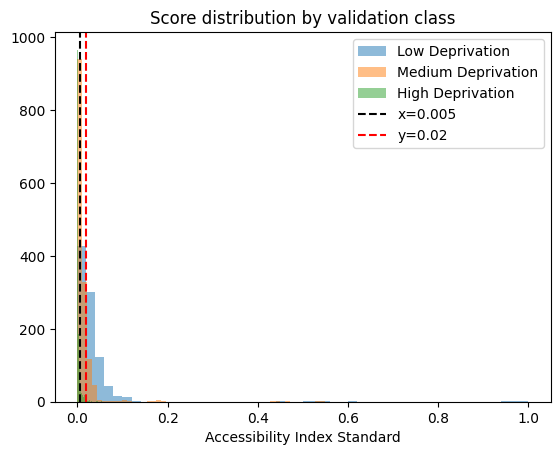

In [15]:
for label, name in zip([0, 1, 2], ['Low Deprivation', 'Medium Deprivation', 'High Deprivation']):
    subset = accessibility_index[accessibility_index['validation'] == label]['Accessibility_Index_Standard']
    plt.hist(subset, bins=50, alpha=0.5, label=name)

plt.axvline(0.005, color='black', linestyle='--', label='x=0.005')
plt.axvline(0.02, color='red', linestyle='--', label='y=0.02')
plt.legend()
plt.xlabel('Accessibility Index Standard')
plt.title('Score distribution by validation class')
plt.show()

In [12]:
# Fix dtype
accessibility_index['validation'] = accessibility_index['validation'].astype(int)

def optimize_thresholds_f1(df, score_col='Accessibility_Index_Standard', label_col='validation', n=100):
    candidates  = np.linspace(df[score_col].min(), df[score_col].max(), n)
    scores      = df[score_col].values
    true_labels = df[label_col].values.astype(int)
    best_x, best_y, best_f1 = 0, 0, -1

    for i, x in enumerate(candidates):
        for y in candidates[i+1:]:
            preds = np.where(scores > y, 0, np.where(scores > x, 1, 2))
            f1 = f1_score(true_labels, preds, average='macro', zero_division=0)
            if f1 > best_f1:
                best_f1, best_x, best_y = f1, x, y

    return best_x, best_y, best_f1

# Coarse search
coarse_x, coarse_y, _ = optimize_thresholds_f1(accessibility_index)

# Fine search within ±0.05 of coarse result
def fine_search(df, cx, cy, score_col='Accessibility_Index_Standard', label_col='validation', n=100):
    df_fine = df.copy()
    # Temporarily override candidates range
    return optimize_thresholds_f1(
        df[df[score_col].between(max(0, cx-0.05), min(1, cy+0.05))],
        n=n
    )

optimal_x, optimal_y, best_f1 = fine_search(accessibility_index, coarse_x, coarse_y)

print(f"x={optimal_x:.4f}, y={optimal_y:.4f}, Macro F1={best_f1:.4f}")

x=0.0050, y=0.0198, Macro F1=0.6906


In [14]:
from sklearn.metrics import classification_report

accessibility_index['optimised_result'] = np.where(
    accessibility_index['Accessibility_Index_Standard'] >= optimal_y, 0,
    np.where(accessibility_index['Accessibility_Index_Standard'] >= optimal_x, 1, 2)
).astype(int)

print(classification_report(
    accessibility_index['validation'],
    accessibility_index['optimised_result'],
    target_names=['Low deprivation (0)', 'Medium deprivation (1)', 'High deprivation (2)']
))

                        precision    recall  f1-score   support

   Low deprivation (0)       0.66      0.54      0.60       932
Medium deprivation (1)       0.71      0.68      0.70      1469
  High deprivation (2)       0.75      0.83      0.79      2033

              accuracy                           0.72      4434
             macro avg       0.71      0.69      0.69      4434
          weighted avg       0.72      0.72      0.72      4434



In [16]:
print("=== Original (output_result) ===")
print(classification_report(
    accessibility_index['validation'],
    accessibility_index['output_result'].astype(int),
    target_names=['Low deprivation (0)', 'Medium deprivation (1)', 'High deprivation (2)']
))

print("=== Optimised ===")
print(classification_report(
    accessibility_index['validation'],
    accessibility_index['optimised_result'],
    target_names=['Low deprivation (0)', 'Medium deprivation (1)', 'High deprivation (2)']
))

=== Original (output_result) ===
                        precision    recall  f1-score   support

   Low deprivation (0)       0.66      0.54      0.60       932
Medium deprivation (1)       0.71      0.68      0.69      1469
  High deprivation (2)       0.75      0.83      0.79      2033

              accuracy                           0.72      4434
             macro avg       0.71      0.69      0.69      4434
          weighted avg       0.72      0.72      0.72      4434

=== Optimised ===
                        precision    recall  f1-score   support

   Low deprivation (0)       0.66      0.54      0.60       932
Medium deprivation (1)       0.71      0.68      0.70      1469
  High deprivation (2)       0.75      0.83      0.79      2033

              accuracy                           0.72      4434
             macro avg       0.71      0.69      0.69      4434
          weighted avg       0.72      0.72      0.72      4434



### This is the code from Prof Zhao

In [10]:
# 1. THE OPTIMIZATION ALGORITH
def optimize_thresholds(df, score_col='Accessibility_Index_Standard', label_col='validation'):
    """
    Finds optimal x and y thresholds to maximise Macro F1 score.
    score >= y  → 0 (Low Deprivation / High Accessibility)
    x <= score < y → 1 (Medium Deprivation)
    score < x   → 2 (High Deprivation / Low Accessibility)
    Uses 200 quantile-based candidates to balance speed and accuracy.
    """
    candidates  = np.sort(np.unique(np.quantile(df[score_col], np.linspace(0, 1, 200))))
    scores      = df[score_col].values
    true_labels = df[label_col].values.astype(int)

    best_x, best_y, best_f1 = 0, 0, -1

    # Iterate through all valid pairs of x and y (where x < y)
    for i in range(len(candidates)):
        x = candidates[i]

        # y must be greater than x
        for j in range(i + 1, len(candidates)):
            y = candidates[j]

            # High accessibility (low deprivation) = high score
            predictions = np.where(scores >= y, 0,
                          np.where(scores >= x, 1, 2))

            # Macro F1 handles class imbalance better than accuracy
            f1 = f1_score(true_labels, predictions, average='macro', zero_division=0)

            if f1 > best_f1:
                best_f1 = f1
                best_x, best_y = x, y

    # Calculate final accuracy
    final_preds = np.where(scores >= best_y, 0, np.where(scores >= best_x, 1, 2))
    accuracy = (np.sum(final_preds == true_labels) / len(df)) * 100

    return best_x, best_y, best_f1, accuracy


# 2. RUN THE OPTIMIZER
print("Running optimization...")
optimal_x, optimal_y, best_f1, accuracy_pct = optimize_thresholds(accessibility_index)

print("-" * 30)
print("OPTIMIZATION RESULTS")
print("-" * 30)
print(f"Best x threshold (High / Medium split): {optimal_x:.6f}  (original: 0.005000)")
print(f"Best y threshold (Medium / Low split):  {optimal_y:.6f}  (original: 0.020000)")
print(f"Macro F1:  {best_f1:.4f}")
print(f"Accuracy:  {accuracy_pct:.2f}%")


# 3. APPLY OPTIMAL THRESHOLDS
accessibility_index['optimised_result'] = np.where(
    accessibility_index['Accessibility_Index_Standard'] >= optimal_y, 0,
    np.where(accessibility_index['Accessibility_Index_Standard'] >= optimal_x, 1, 2)
).astype(int)

print("\nClassification Report:")
print(classification_report(
    accessibility_index['validation'],
    accessibility_index['optimised_result'],
    target_names=['Low deprivation (0)', 'Medium deprivation (1)', 'High deprivation (2)']
))

Running optimization...
------------------------------
OPTIMIZATION RESULTS
------------------------------
Best x threshold (High / Medium split): 0.005017  (original: 0.005000)
Best y threshold (Medium / Low split):  0.019448  (original: 0.020000)
Macro F1:  0.6916
Accuracy:  72.01%

Classification Report:
                        precision    recall  f1-score   support

   Low deprivation (0)       0.65      0.55      0.59       932
Medium deprivation (1)       0.71      0.68      0.69      1469
  High deprivation (2)       0.75      0.83      0.79      2033

              accuracy                           0.72      4434
             macro avg       0.70      0.68      0.69      4434
          weighted avg       0.72      0.72      0.72      4434



In [11]:
print("=== Original (output_result) ===")
print(classification_report(
    accessibility_index['validation'],
    accessibility_index['output_result'].astype(int),
    target_names=['Low deprivation (0)', 'Medium deprivation (1)', 'High deprivation (2)']
))

print("=== Optimised ===")
print(classification_report(
    accessibility_index['validation'],
    accessibility_index['optimised_result'],
    target_names=['Low deprivation (0)', 'Medium deprivation (1)', 'High deprivation (2)']
))

=== Original (output_result) ===
                        precision    recall  f1-score   support

   Low deprivation (0)       0.66      0.54      0.60       932
Medium deprivation (1)       0.71      0.68      0.69      1469
  High deprivation (2)       0.75      0.83      0.79      2033

              accuracy                           0.72      4434
             macro avg       0.71      0.69      0.69      4434
          weighted avg       0.72      0.72      0.72      4434

=== Optimised ===
                        precision    recall  f1-score   support

   Low deprivation (0)       0.65      0.55      0.59       932
Medium deprivation (1)       0.71      0.68      0.69      1469
  High deprivation (2)       0.75      0.83      0.79      2033

              accuracy                           0.72      4434
             macro avg       0.70      0.68      0.69      4434
          weighted avg       0.72      0.72      0.72      4434



### GRID SEARCH + F1 SURFACE

Best x: 0.005017
Best y: 0.019448
Macro F1: 0.6916


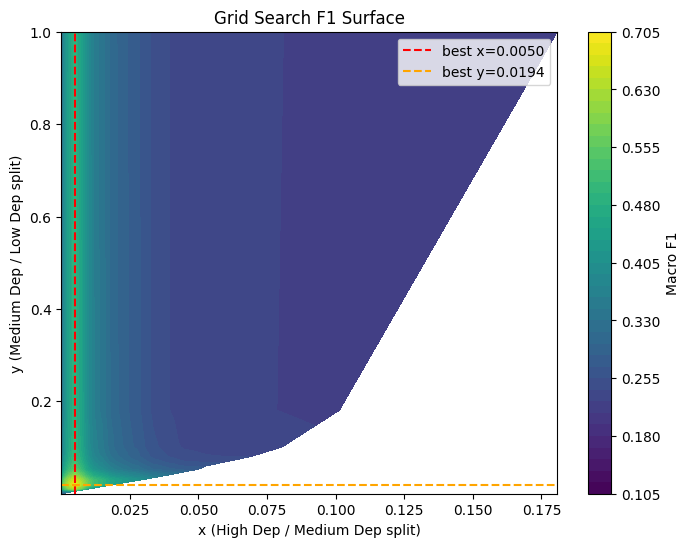

In [ ]:
# Define grid
grid = np.sort(np.unique(np.quantile(
    accessibility_index['Accessibility_Index_Standard'], 
    np.linspace(0, 1, 200)
)))

scores      = accessibility_index['Accessibility_Index_Standard'].values
true_labels = accessibility_index['validation'].values.astype(int)

best_x, best_y, best_f1 = 0, 0, -1
results = []

for x, y in product(grid, grid):
    if x >= y:
        continue
    
    # Low score = High Deprivation (2), High score = Low Deprivation (0)
    preds = np.where(scores >= y, 0, np.where(scores >= x, 1, 2))
    f1 = f1_score(true_labels, preds, average='macro', zero_division=0)
    results.append({'x': x, 'y': y, 'f1': f1})
    
    if f1 > best_f1:
        best_f1, best_x, best_y = f1, x, y

print(f"Best x: {best_x:.6f}")
print(f"Best y: {best_y:.6f}")
print(f"Macro F1: {best_f1:.4f}")

# Visualise F1 surface
results_df = pd.DataFrame(results)
pivot = results_df.pivot_table(index='y', columns='x', values='f1')

plt.figure(figsize=(8, 6))
plt.contourf(pivot.columns, pivot.index, pivot.values, levels=50, cmap='viridis')
plt.colorbar(label='Macro F1')
plt.axvline(best_x, color='red', linestyle='--', label=f'best x={best_x:.4f}')
plt.axhline(best_y, color='orange', linestyle='--', label=f'best y={best_y:.4f}')
plt.xlabel('x (High Dep / Medium Dep split)')
plt.ylabel('y (Medium Dep / Low Dep split)')
plt.title('Grid Search F1 Surface')
plt.legend()
plt.show()

### Lagos

In [34]:
# Select pilot city
pilot = 'Nairobi'  # Change this to the desired pilot city
# Load PAR data and filter by pilot city
# par_expanded = pd.read_csv('/content/expanded_data.csv') # You need to upload this file
par_expanded = validation_df[validation_df['output_model_city_name'] == f'{pilot.capitalize()}']

In [35]:
# Describe the shape of the validation data
print("Shape of PAR Data", par_expanded.shape)
par_expanded['output_model_subdomain_name'].value_counts()

Shape of PAR Data (28317, 12)


output_model_subdomain_name
Morphological Informality                      11956
Road Access Deprivation                         7125
Emergency Obstetric Care Access Deprivation     3187
Flood Hazard                                    3095
Accumulated Waste Piles                         2873
General Healthcare Access Deprivation             81
Name: count, dtype: int64

In [54]:
# Enter subdomain
subdomain = 'Emergency Obstetric Care Access Deprivation'  # Change this to the desired subdomain

# Filter Data by Subdomain
par_subdomain_Nairobi = par_expanded[par_expanded['output_model_subdomain_name'] == subdomain]
par_subdomain_Nairobi.head()

,id,created_at,validation,user_id,output_id,output_model,output_model_city_name,output_model_city_country,output_model_subdomain_name,output_result,output_latitude,output_longitude
47958,a3a4c625-96d3-4607-9b99-f232514ad4c0,2025-07-30T08:07:46.237607+00:00,1.0,3238d1a6-7f40-41b0-bd06-d94417973916,708e6586-3e7c-4b0a-8efc-144988afa1e3,670877f9-f857-498d-b95a-f1fa077bc158,Nairobi,Kenya,Emergency Obstetric Care Access Deprivation,1,-1.316314,36.883359
48643,387489fc-7fa1-496e-b1ea-1914c2352d06,2025-07-30T08:05:01.990103+00:00,2.0,3238d1a6-7f40-41b0-bd06-d94417973916,cedcac24-4f7f-4f81-87b8-8146379195f0,670877f9-f857-498d-b95a-f1fa077bc158,Nairobi,Kenya,Emergency Obstetric Care Access Deprivation,1,-1.316314,36.881363
74230,46aa1ea2-250f-447a-b686-3fbbd7a67feb,2025-07-30T12:56:56.286148+00:00,0.0,bae64293-90a7-4d01-b833-6a3fb2dd57ec,892e9666-d1df-412b-93b3-6a18d2195a84,670877f9-f857-498d-b95a-f1fa077bc158,Nairobi,Kenya,Emergency Obstetric Care Access Deprivation,0,-1.314696,36.842428
74249,4213171f-ed7d-4d56-82f3-30cd36165d62,2025-07-30T12:57:00.998008+00:00,1.0,bae64293-90a7-4d01-b833-6a3fb2dd57ec,90b697fb-c13b-4d93-857b-f5707813db79,670877f9-f857-498d-b95a-f1fa077bc158,Nairobi,Kenya,Emergency Obstetric Care Access Deprivation,0,-1.313888,36.842421
74254,ba0f3f6e-1fbf-4d7d-8c66-1bd61cb0a767,2025-07-30T12:57:13.453612+00:00,1.0,bae64293-90a7-4d01-b833-6a3fb2dd57ec,6c9b77ce-e78b-44ba-9ab5-3ef37c645ffc,670877f9-f857-498d-b95a-f1fa077bc158,Nairobi,Kenya,Emergency Obstetric Care Access Deprivation,0,-1.313888,36.841423


In [55]:
accessibility_index_Nairobi = gpd.read_file('deprivation-classification-Nairobi.gpkg')
print(accessibility_index_Nairobi.columns)

Index(['grid_id', 'hcf_id', 'longitude_hcf', 'latitude_hcf', 'facility_name',
       'local_validation', 'population', 'duration_seconds', 'distance_km',
       'Weight', 'Pop_W_x', 'Pop_W_S', 'supply_demand_ratio', 'supply_W',
       'Accessibility', 'supply', 'Accessibility_standard', 'result',
       'focused', 'lon_min', 'lat_min', 'lon_max', 'lat_max', 'geometry'],
      dtype='object')


In [56]:
par_gdf = gpd.GeoDataFrame(
    par_subdomain_Nairobi,
    geometry=gpd.points_from_xy(par_subdomain_Nairobi['output_longitude'], 
                                 par_subdomain_Nairobi['output_latitude']),
    crs=accessibility_index_Nairobi.crs
)

joined = gpd.sjoin(par_gdf, accessibility_index_Nairobi[['Accessibility_standard', 'geometry']], 
                    how="left", predicate="within")

par_subdomain_Nairobi = par_subdomain_Nairobi.copy()
par_subdomain_Nairobi['Accessibility_standard'] = joined['Accessibility_standard'].values
par_subdomain_Nairobi

,id,created_at,validation,user_id,output_id,output_model,output_model_city_name,output_model_city_country,output_model_subdomain_name,output_result,output_latitude,output_longitude,Accessibility_standard
47958,a3a4c625-96d3-4607-9b99-f232514ad4c0,2025-07-30T08:07:46.237607+00:00,1.0,3238d1a6-7f40-41b0-bd06-d94417973916,708e6586-3e7c-4b0a-8efc-144988afa1e3,670877f9-f857-498d-b95a-f1fa077bc158,Nairobi,Kenya,Emergency Obstetric Care Access Deprivation,1,-1.316314,36.883359,0.068815
48643,387489fc-7fa1-496e-b1ea-1914c2352d06,2025-07-30T08:05:01.990103+00:00,2.0,3238d1a6-7f40-41b0-bd06-d94417973916,cedcac24-4f7f-4f81-87b8-8146379195f0,670877f9-f857-498d-b95a-f1fa077bc158,Nairobi,Kenya,Emergency Obstetric Care Access Deprivation,1,-1.316314,36.881363,0.063474
74230,46aa1ea2-250f-447a-b686-3fbbd7a67feb,2025-07-30T12:56:56.286148+00:00,0.0,bae64293-90a7-4d01-b833-6a3fb2dd57ec,892e9666-d1df-412b-93b3-6a18d2195a84,670877f9-f857-498d-b95a-f1fa077bc158,Nairobi,Kenya,Emergency Obstetric Care Access Deprivation,0,-1.314696,36.842428,0.128580
74249,4213171f-ed7d-4d56-82f3-30cd36165d62,2025-07-30T12:57:00.998008+00:00,1.0,bae64293-90a7-4d01-b833-6a3fb2dd57ec,90b697fb-c13b-4d93-857b-f5707813db79,670877f9-f857-498d-b95a-f1fa077bc158,Nairobi,Kenya,Emergency Obstetric Care Access Deprivation,0,-1.313888,36.842421,0.126473
74254,ba0f3f6e-1fbf-4d7d-8c66-1bd61cb0a767,2025-07-30T12:57:13.453612+00:00,1.0,bae64293-90a7-4d01-b833-6a3fb2dd57ec,6c9b77ce-e78b-44ba-9ab5-3ef37c645ffc,670877f9-f857-498d-b95a-f1fa077bc158,Nairobi,Kenya,Emergency Obstetric Care Access Deprivation,0,-1.313888,36.841423,0.123970
...,...,...,...,...,...,...,...,...,...,...,...,...,...
84061,b0f0affa-eeed-4862-8998-bf963e884a87,2025-09-11T12:42:14.821978+00:00,1.0,05ec794f-ba27-4489-a84b-819b1f4b6463,d66e5306-3368-461a-9f69-6551558ac3be,670877f9-f857-498d-b95a-f1fa077bc158,Nairobi,Kenya,Emergency Obstetric Care Access Deprivation,1,-1.313079,36.877341,0.071563
84131,960eec03-7a06-41c7-910c-aae4e64a863d,2025-09-11T12:41:17.474516+00:00,2.0,05ec794f-ba27-4489-a84b-819b1f4b6463,9bcd1fcf-f49d-4bab-baec-64689b790fdc,670877f9-f857-498d-b95a-f1fa077bc158,Nairobi,Kenya,Emergency Obstetric Care Access Deprivation,1,-1.311461,36.878325,0.067899
84164,802258bc-e847-4c06-a6c7-4f007c6ca730,2025-09-11T12:41:46.783354+00:00,2.0,05ec794f-ba27-4489-a84b-819b1f4b6463,c147a676-c315-4162-98ef-a5ffaa32d7ae,670877f9-f857-498d-b95a-f1fa077bc158,Nairobi,Kenya,Emergency Obstetric Care Access Deprivation,1,-1.313079,36.872352,0.074082
84172,382185e5-635a-49f2-926c-f153d5b2cd22,2025-09-11T12:42:01.22126+00:00,2.0,05ec794f-ba27-4489-a84b-819b1f4b6463,04629599-9807-4634-9e37-2259f6b67bcb,670877f9-f857-498d-b95a-f1fa077bc158,Nairobi,Kenya,Emergency Obstetric Care Access Deprivation,1,-1.312270,36.875338,0.072323


In [57]:
def optimize_thresholds(df, score_col='Accessibility_standard', label_col='validation'):
    candidates  = np.sort(np.unique(np.quantile(df[score_col].dropna(), np.linspace(0, 1, 200))))
    scores      = df[score_col].values
    true_labels = df[label_col].values.astype(int)
    best_x, best_y, best_f1 = 0, 0, -1
    for i in range(len(candidates)):
        x = candidates[i]
        for j in range(i + 1, len(candidates)):
            y = candidates[j]
            predictions = np.where(scores >= y, 0,
                          np.where(scores >= x, 1, 2))
            f1 = f1_score(true_labels, predictions, average='macro', zero_division=0)
            if f1 > best_f1:
                best_f1 = f1
                best_x, best_y = x, y
    final_preds = np.where(scores >= best_y, 0, np.where(scores >= best_x, 1, 2))
    accuracy = (np.sum(final_preds == true_labels) / len(df)) * 100
    return best_x, best_y, best_f1, accuracy

# Run on par_subdomain_Nairobi instead of accessibility_index
print("Running optimization...")
optimal_x, optimal_y, best_f1, accuracy_pct = optimize_thresholds(par_subdomain_Nairobi)
print("-" * 30)
print("OPTIMIZATION RESULTS")
print("-" * 30)
print(f"Best x threshold (High / Medium split): {optimal_x:.6f}")
print(f"Best y threshold (Medium / Low split):  {optimal_y:.6f}")
print(f"Macro F1:  {best_f1:.4f}")
print(f"Accuracy:  {accuracy_pct:.2f}%")

# Apply optimal thresholds
par_subdomain_Nairobi['optimised_result'] = np.where(
    par_subdomain_Nairobi['Accessibility_standard'] >= optimal_y, 0,
    np.where(par_subdomain_Nairobi['Accessibility_standard'] >= optimal_x, 1, 2)
).astype(int)

print("\nClassification Report:")
print(classification_report(
    par_subdomain_Nairobi['validation'],
    par_subdomain_Nairobi['optimised_result'],
    target_names=['Low deprivation (0)', 'Medium deprivation (1)', 'High deprivation (2)']
))

Running optimization...
------------------------------
OPTIMIZATION RESULTS
------------------------------
Best x threshold (High / Medium split): 0.043557
Best y threshold (Medium / Low split):  0.056020
Macro F1:  0.6644
Accuracy:  68.75%

Classification Report:
                        precision    recall  f1-score   support

   Low deprivation (0)       0.61      0.44      0.51      1039
Medium deprivation (1)       0.80      0.62      0.69       848
  High deprivation (2)       0.68      0.93      0.79      1300

              accuracy                           0.69      3187
             macro avg       0.70      0.66      0.66      3187
          weighted avg       0.69      0.69      0.67      3187



In [59]:
print("=== Original (output_result) ===")
print(classification_report(
    par_subdomain_Nairobi['validation'],
    par_subdomain_Nairobi['output_result'].astype(int),
    target_names=['Low deprivation (0)', 'Medium deprivation (1)', 'High deprivation (2)']
))

print("=== Optimised ===")
print(classification_report(
    par_subdomain_Nairobi['validation'],
    par_subdomain_Nairobi['optimised_result'],
    target_names=['Low deprivation (0)', 'Medium deprivation (1)', 'High deprivation (2)']
))

=== Original (output_result) ===
                        precision    recall  f1-score   support

   Low deprivation (0)       0.77      0.26      0.39      1039
Medium deprivation (1)       0.65      0.81      0.72       848
  High deprivation (2)       0.68      0.93      0.79      1300

              accuracy                           0.68      3187
             macro avg       0.70      0.67      0.63      3187
          weighted avg       0.70      0.68      0.64      3187

=== Optimised ===
                        precision    recall  f1-score   support

   Low deprivation (0)       0.61      0.44      0.51      1039
Medium deprivation (1)       0.80      0.62      0.69       848
  High deprivation (2)       0.68      0.93      0.79      1300

              accuracy                           0.69      3187
             macro avg       0.70      0.66      0.66      3187
          weighted avg       0.69      0.69      0.67      3187

